# Swaps-short trajectory exploration

Dataset: `data/N40K-compress-LJ10-T0.001-F0.61-damp4.0_stage1_trial33_dt100-dr200__swaps-short.txt`

Tab-separated columns: snap index, corrected snap count, simulation time, snap direction, and bond-center coordinates (x, y).

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DATA_NAME = "N40K-compress-LJ10-T0.001-F0.61-damp4.0_stage1_trial33_dt100-dr200__swaps-short.txt"


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        for rel in (Path("data") / DATA_NAME, Path("crumpling") / "data" / DATA_NAME):
            if (p / rel).is_file():
                return (p / rel).parent.parent if rel.parts[0] == "crumpling" else p
    raise FileNotFoundError(
        f"Could not find {DATA_NAME} under {here} or its parents"
    )


ROOT = find_repo_root()
DATA = ROOT / "data" / DATA_NAME


In [3]:
df = pd.read_csv(
    DATA,
    sep="\t",
    engine="python",
)
df.columns = [c.strip() for c in df.columns]
df.head()


,Snap #,Nsnaps (direction corrected),Time,Snap direction,Snap bond c.x,Snap bond c.y
0,1,1,2.934,-1,1084.54500,1849.050
1,2,2,4.005,-1,532.18000,1838.320
2,3,3,4.647,-1,666.59350,1821.440
3,4,4,5.325,-1,229.05050,1849.855
4,5,5,5.562,-1,9.04702,1850.065


In [4]:
print(df.shape)
print(df.dtypes)
df.describe().T


(12575, 6)
Snap #                            int64
Nsnaps (direction corrected)      int64
Time                            float64
Snap direction                    int64
Snap bond c.x                   float64
Snap bond c.y                   float64
dtype: object


,count,mean,std,min,25%,50%,75%,max
Snap #,12575.0,6288.000000,3630.234152,1.00000,3144.50000,6288.0000,9431.5000,12575.000
Nsnaps (direction corrected),12575.0,5425.034115,3002.843750,1.00000,2884.50000,5478.0000,8043.5000,10485.000
Time,12575.0,412160.213364,469582.622358,2.93400,49194.87150,447444.9120,498821.0955,5860387.590
Snap direction,12575.0,-0.833797,0.552093,-1.00000,-1.00000,-1.0000,-1.0000,1.000
Snap bond c.x,12575.0,902.887767,521.748903,3.35178,437.11900,918.6570,1365.5775,1851.315
Snap bond c.y,12575.0,920.597700,523.221733,2.81314,473.66825,932.0925,1378.2075,1850.065


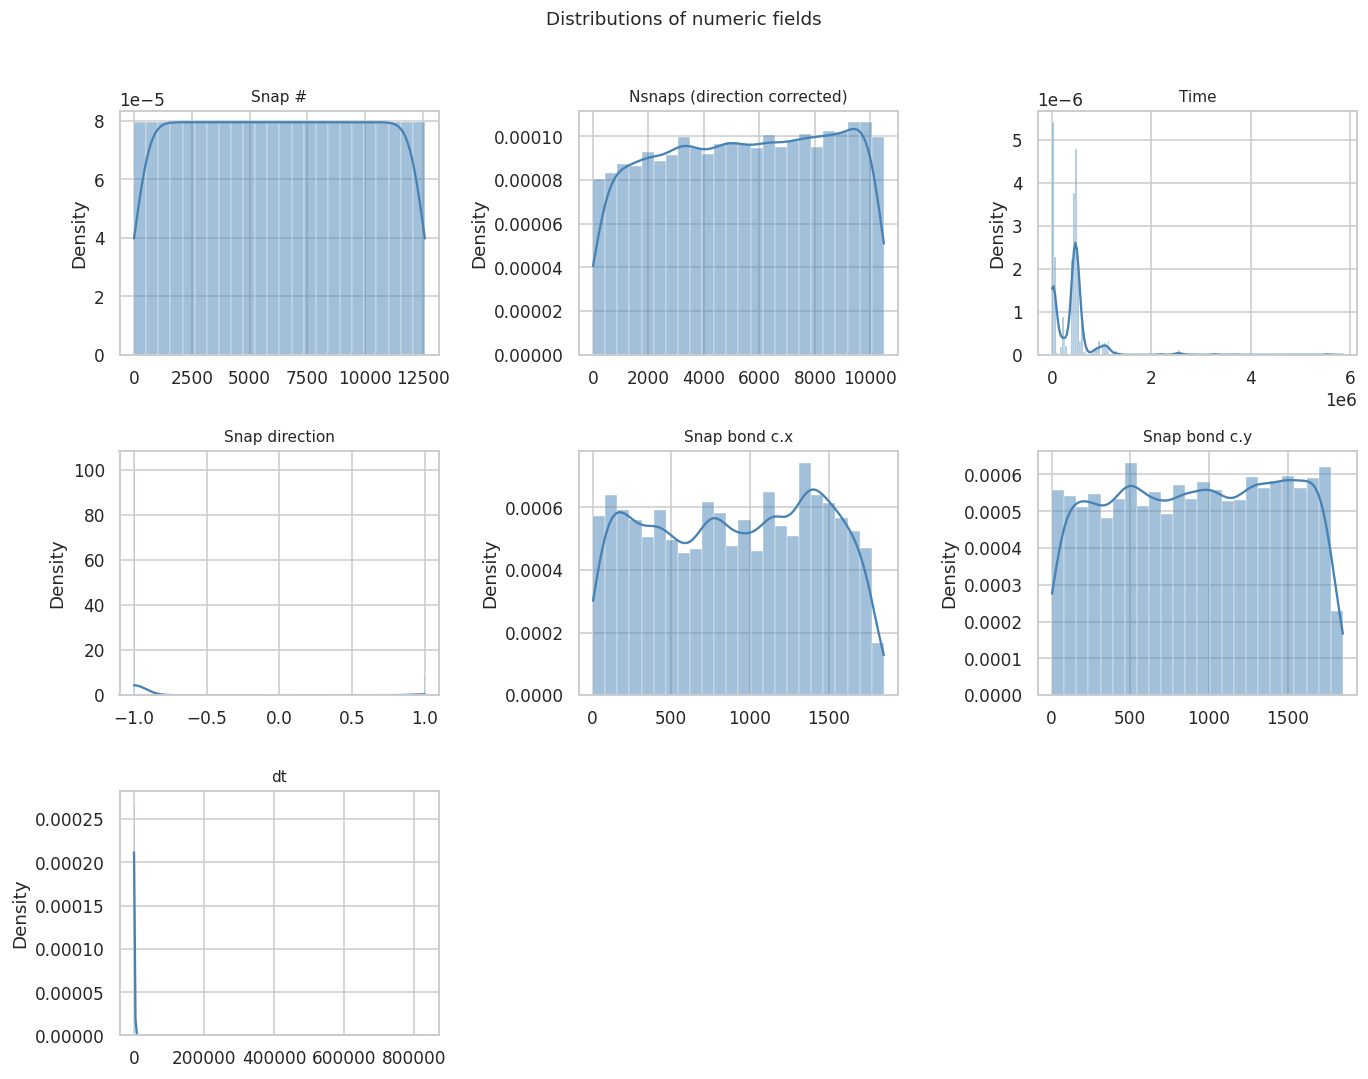

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
ncols = 3
nrows = int(np.ceil(len(num_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, stat="density", color="steelblue", edgecolor="white", linewidth=0.25)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Distributions of numeric fields", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


In [10]:
time_col = "Time"
if time_col not in df.columns:
    time_col = [c for c in df.columns if "time" in c.lower()][0]

df["dt"] = df[time_col].diff()
df["dt"].iloc[0] = np.nan


/tmp/ipykernel_19531/3802827210.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df["dt"].iloc[0] = np.nan


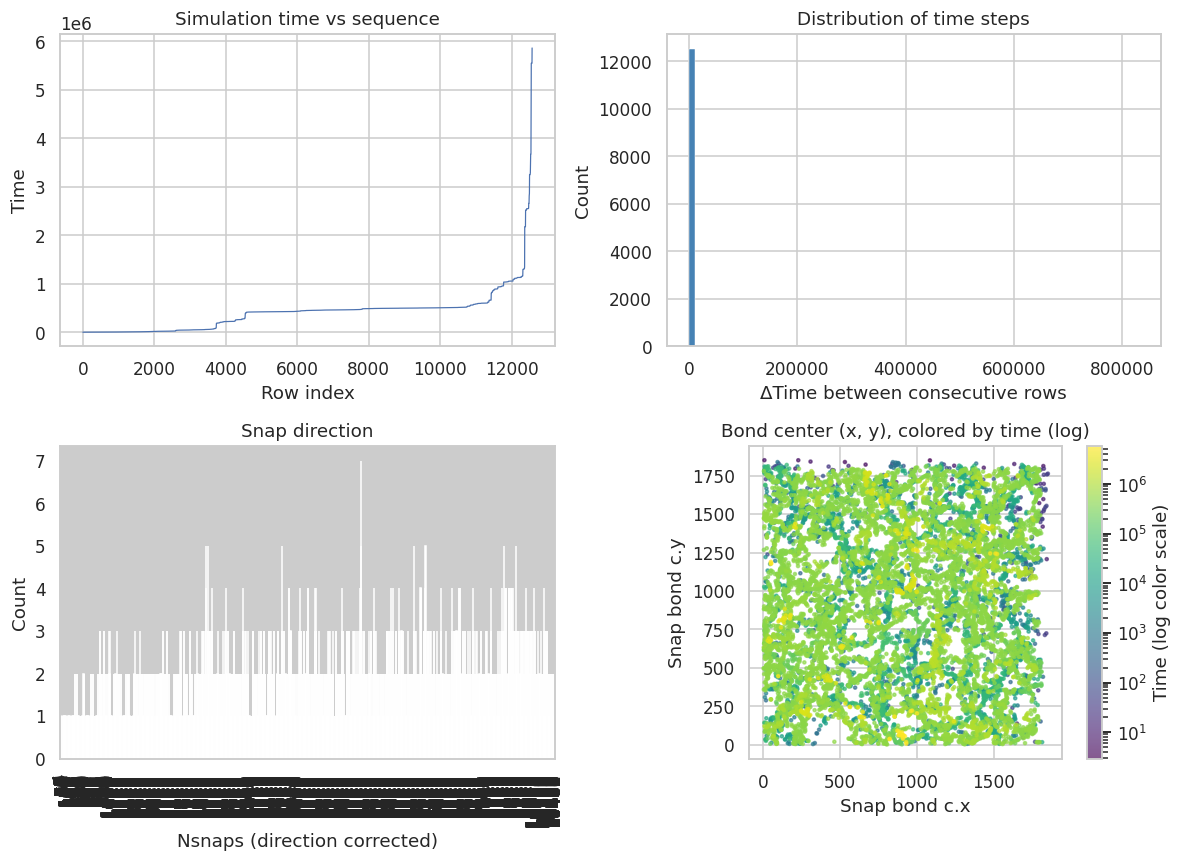

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
ax.plot(df.index, df[time_col], lw=0.8)
ax.set_xlabel("Row index")
ax.set_ylabel(time_col)
ax.set_title("Simulation time vs sequence")

ax = axes[0, 1]
ax.hist(df["dt"].dropna(), bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_xlabel(f"Δ{time_col} between consecutive rows")
ax.set_ylabel("Count")
ax.set_title("Distribution of time steps")

dir_col = [c for c in df.columns if "direction" in c.lower()][0]
ax = axes[1, 0]
vc = df[dir_col].value_counts().sort_index()
vc.plot(kind="bar", ax=ax, color="coral", edgecolor="white")
ax.set_xlabel(dir_col)
ax.set_ylabel("Count")
ax.set_title("Snap direction")

cx = [c for c in df.columns if "c.x" in c or c.endswith(".x")][0]
cy = [c for c in df.columns if "c.y" in c or c.endswith(".y")][0]
ax = axes[1, 1]
tvals = df[time_col].to_numpy()
vmin, vmax = np.nanmin(tvals), np.nanmax(tvals)
sc = ax.scatter(
    df[cx],
    df[cy],
    c=tvals,
    s=4,
    cmap="viridis",
    alpha=0.65,
    norm=LogNorm(vmin=max(vmin, np.finfo(float).tiny), vmax=vmax),
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(f"{time_col} (log color scale)")
ax.set_xlabel(cx)
ax.set_ylabel(cy)
ax.set_title("Bond center (x, y), colored by time (log)")
ax.set_aspect("equal", adjustable="box")

fig.tight_layout()
plt.show()


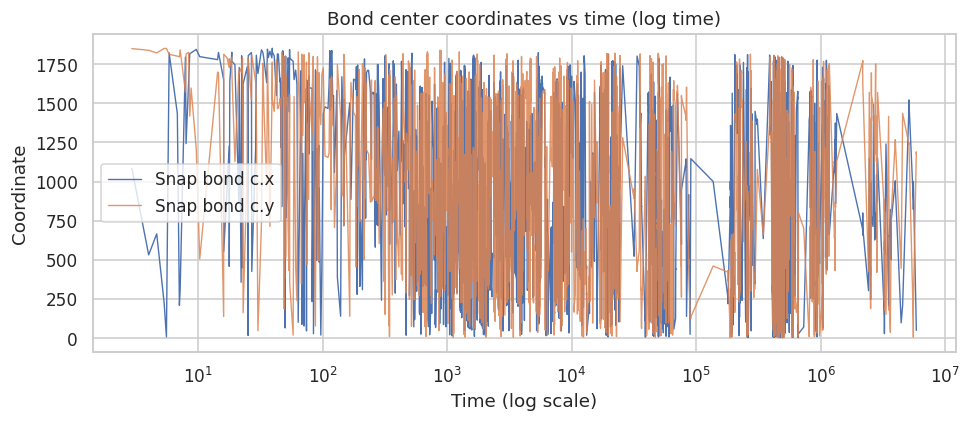

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df[time_col], df[cx], label=cx, lw=0.9)
ax.plot(df[time_col], df[cy], label=cy, lw=0.9, alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel(f"{time_col} (log scale)")
ax.set_ylabel("Coordinate")
ax.set_title("Bond center coordinates vs time (log time)")
ax.legend()
fig.tight_layout()
plt.show()


In [16]:
from scipy import stats

clean_dt = df["dt"].dropna()
print("Δtime summary (excluding first NaN):")
print(clean_dt.describe())
print("\nSkew / kurtosis:", stats.skew(clean_dt), stats.kurtosis(clean_dt, fisher=True))


Δtime summary (excluding first NaN):
count     12574.000000
mean        466.071628
std       12313.700617
min           0.000000
25%           0.864000
50%           2.050500
75%           4.890000
max      830385.933000
Name: dt, dtype: float64

Skew / kurtosis: 45.24188356041933 2403.7726272759032
